In [ ]:
import pandas as pd
import requests

# 1. Configuration for Oncology Market Analysis
DISEASE_TYPE = "malignant neoplasm" # This captures cancer-related reports
TOTAL_RECORDS = 5000                # 5000 samples
LIMIT_PER_QUERY = 100

def fetch_oncology_insights(indication, total_needed):
    all_records = []

    for skip in range(0, total_needed, LIMIT_PER_QUERY):
        # We search by 'indication' to see all drugs used for Cancer
        url = f"https://api.fda.gov/drug/event.json?search=patient.drug.drugindication:{indication}&limit={LIMIT_PER_QUERY}&skip={skip}"

        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            all_records.extend(data['results'])
            print(f"Retrieved {len(all_records)} Oncology records...")
        else:
            print(f"Error: {response.status_code}")
            break

    return all_records

# 2. Extracting Data
raw_data = fetch_oncology_insights(DISEASE_TYPE, TOTAL_RECORDS)

# 3. Processing for Commercial Excellence (Competitive Intelligence)
processed_data = []
for record in raw_data:
    # Oncology drugs are often taken in combinations, so we grab the first one listed
    drug_list = record.get('patient', {}).get('drug', [])
    drug_name = drug_list[0].get('medicinalproduct', 'Unknown') if drug_list else "Unknown"

    reactions = record.get('patient', {}).get('reaction', [])
    primary_reaction = reactions[0].get('reactionmeddrapt') if reactions else "Unknown"

    processed_data.append({
        "Report_ID": record.get('safetyreportid'),
        "Drug_Name": drug_name,
        "Reaction": primary_reaction,
        "Serious_Case": "Yes" if record.get('serious') == "1" else "No",
        "Country": record.get('occurcountry'),
        "Patient_Age": record.get('patient', {}).get('patientonsetage', 'N/A')
    })

df = pd.DataFrame(processed_data)

# 4. Clean up the Drug Names (making them easier to read for the Board Meeting)
df['Drug_Name'] = df['Drug_Name'].str.upper()

df.to_csv("Oncology_Market_Analysis.csv", index=False)
print("Oncology Market Report Generated.")

In [ ]:
df.isnull().sum()

In [ ]:
na_patient_age_count = df[df['Patient_Age'] == 'N/A'].shape[0]
print(f"Number of 'N/A' entries in 'Patient_Age' column: {na_patient_age_count}")

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df['Drug_Name'].unique()

In [ ]:
df['Drug_Name'].nunique()

In [ ]:
# Get unique names, but convert to uppercase and strip whitespace first
df['Drug_Name_Clean'] = df['Drug_Name'].str.upper().str.strip()

# Create a master list of unique drugs and how often they appear
unique_drugs = df['Drug_Name_Clean'].value_counts().reset_index()
unique_drugs.columns = ['Drug_Name', 'Frequency']

# View the top 20 unique items
print(unique_drugs.head(20))

In [ ]:
# import difflib

# unique_list = df['Drug_Name_Clean'].unique().tolist()

# # Find names similar to 'PACLITAXEL'
# matches = difflib.get_close_matches('PACLITAXEL', unique_list, n=10, cutoff=0.6)
# print(f"Close matches found: {matches}")

In [ ]:
!pip install thefuzz

In [ ]:
import pandas as pd
from thefuzz import process, fuzz

# The top 20 unique items
drug_list = [
    "TARCEVA", "XALKORI", "ZELBORAF", "XTANDI", "YERVOY",
    "IPILIMUMAB", "HUMIRA", "ENBREL", "LETROZOLE", "GLIVEC",
    "VEMURAFENIB", "SUTENT", "AVASTIN", "AFINITOR", "MEKINIST",
    "TAFINLAR", "ERLOTINIB", "DABRAFENIB", "VOTRIENT", "REMICADE"
]

# Mapping the high-confidence brand/generic pairs manually
# Fuzzy matching helps us find variations, but for brand/generic,

mapping_dict = {
    "IPILIMUMAB": "YERVOY",
    "ERLOTINIB": "TARCEVA",
    "VEMURAFENIB": "ZELBORAF",
    "DABRAFENIB": "TAFINLAR"
}

# Standardizing the list
standardized_list = [mapping_dict.get(drug, drug) for drug in drug_list]

# Checking for any remaining "Fuzzy" duplicates (e.g., misspellings)
matches = []
for drug in set(standardized_list):
    # Find similar names within the same list (excluding exact self-matches)
    potential = process.extract(drug, [x for x in set(standardized_list) if x != drug], limit=1, scorer=fuzz.token_sort_ratio)
    for name, score in potential:
        if score > 70: # High similarity threshold
            matches.append((drug, name, score))

print("Final Cleaned List Sample:", standardized_list[:10])
print("Fuzzy matches to investigate:", matches)

In [ ]:
# Apply the mapping_dict to the 'Drug_Name_Clean' column
df['Drug_Name_Clean_Mapped'] = df['Drug_Name_Clean'].replace(mapping_dict)

# Display the head of the DataFrame with the new column
display(df[['Drug_Name_Clean', 'Drug_Name_Clean_Mapped']].head())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Drug_Name_Clean_Mapped' and count occurrences, then get the top 20
top_20_mapped_drugs = df['Drug_Name_Clean_Mapped'].value_counts().head(20)

# Create a bar chart for the top 20 drugs
plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_mapped_drugs.values, y=top_20_mapped_drugs.index, palette='viridis', hue=top_20_mapped_drugs.index, legend=False)
plt.title('Top 20 Drug Names (Cleaned and Mapped)', fontsize=16)
plt.xlabel('Number of Occurrences', fontsize=12)
plt.ylabel('Drug Name', fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
df.head()

In [ ]:
# Group by 'Drug_Name_Clean_Mapped' and count occurrences, then get the top 20
top_20_mapped_drugs = df['Drug_Name_Clean_Mapped'].value_counts().head(20)

print("Top 20 Drug Names (Cleaned and Mapped):")
print(top_20_mapped_drugs)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by 'Drug_Name_Clean_Mapped' and count occurrences, then get the top 20
top_20_mapped_drugs = df['Drug_Name_Clean_Mapped'].value_counts().head(20)

# Create a bar chart for the top 20 drugs
plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_mapped_drugs.values, y=top_20_mapped_drugs.index, palette='viridis', hue=top_20_mapped_drugs.index, legend=False)
plt.title('Top 20 Drug Names (Cleaned and Mapped)', fontsize=16)
plt.xlabel('Number of Occurrences', fontsize=12)
plt.ylabel('Drug Name', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Category,Drugs from your Top 20,Business Insight
# Oncology (Cancer),"Tarceva, Zelboraf, Xalkori, Xtandi, Yervoy, Tafinlar, Glivec, Avastin, Sutent, Afinitor, Mekinist, Votrient, Xeloda, Sandostatin","This is your largest segment, accounting for 14 of the top 20 drugs. It represents a specialized, high-value market."
# Immunology,"Humira, Enbrel, Remicade","These are ""Blockbuster"" biologic drugs used for autoimmune diseases. They represent a high-volume chronic medication market."
# Neurology / Pain,Lyrica,Focuses on neuropathic pain; a different patient demographic than Oncology.
# Respiratory,Spiriva,Used for chronic lung diseases (COPD/Asthma).
# Hormonal / Other,Letrozole,"Often used in breast cancer treatment, but categorized separately as hormonal therapy."

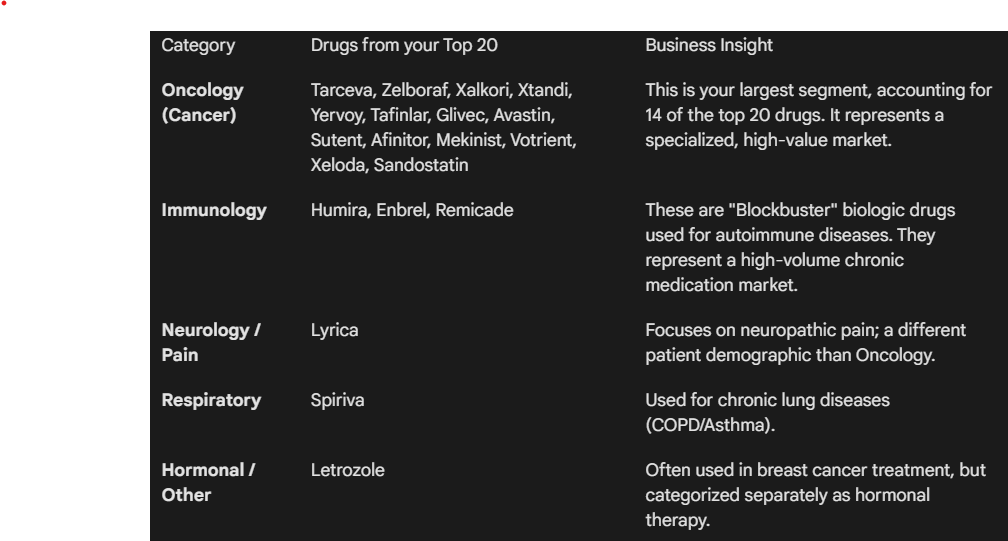

In [ ]:
def get_therapeutic_area(drug):
    oncology = ['TARCEVA', 'ZELBORAF', 'XALKORI', 'XTANDI', 'YERVOY', 'TAFINLAR',
                'GLIVEC', 'AVASTIN', 'SUTENT', 'AFINITOR', 'MEKINIST', 'VOTRIENT',
                'XELODA', 'SANDOSTATIN']
    immunology = ['HUMIRA', 'ENBREL', 'REMICADE']

    if drug in oncology:
        return 'Oncology'
    elif drug in immunology:
        return 'Immunology'
    elif drug == 'LYRICA':
        return 'Neurology'
    elif drug == 'SPIRIVA':
        return 'Respiratory'
    else:
        return 'Hormonal/Other'

# Apply the category to your top 20 list
df['Category'] = df['Drug_Name_Clean_Mapped'].apply(get_therapeutic_area)

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
print(df.isnull().sum())

In [ ]:
na_patient_age_count = df[df['Patient_Age'] == 'N/A'].shape[0]
print(f"Number of 'N/A' entries in 'Patient_Age' column: {na_patient_age_count}")

In [ ]:
# The null values in each column were already displayed after the previous request.
# Here they are again for your convenience:
print(df.isnull().sum())
na_patient_age_count = df[df['Patient_Age'] == 'N/A'].shape[0]
print(f"Number of 'N/A' entries in 'Patient_Age' column: {na_patient_age_count}")

In [ ]:
df.to_excel("Oncology_Market_Analysis.xlsx", index=False)
print("DataFrame exported to Oncology_Market_Analysis.xlsx")

In [ ]:
unique_countries_count = df['Country'].nunique(dropna=True)
print(f"Number of unique countries: {unique_countries_count}")
unique_countries = df['Country'].dropna().unique()
print("Unique countries:")
for country in unique_countries:
    print(country)